# Charger les données 

In [1]:
import pandas as pd

df = pd.read_csv("../data/pos_cotonou.csv")
df.head()


,city,lat,lon,category,name,source
0,Cotonou,6.347745,2.403413,hotel,Arcada Marina,OSM
1,Cotonou,6.349609,2.386550,atm,Ecobank,OSM
2,Cotonou,6.356871,2.404173,hotel,Chant d'oiseau,OSM
3,Cotonou,6.358407,2.431501,pharmacy,Pharmacie Jonquet,OSM
4,Cotonou,6.359506,2.419645,restaurant,Costa Rica,OSM


# Sélection des features

In [2]:
X = df[["lat", "lon"]]

# Clustering avec KMeans

C:\Users\Bernard\anaconda3\envs\tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Bernard\anaconda3\envs\tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Bernard\anaconda3\envs\tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Bernard\anaconda3\envs\tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default 

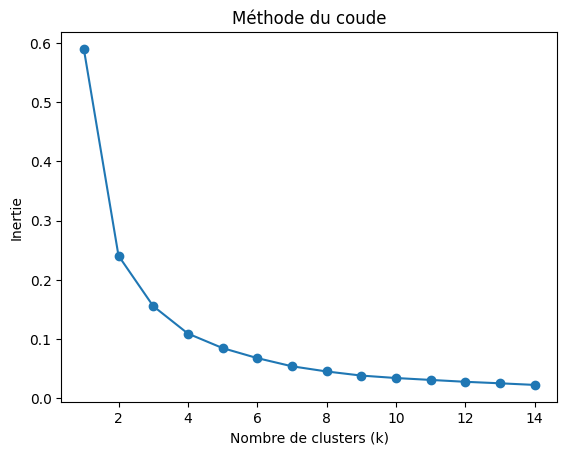

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



inertia = []
K_range = range(1, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()

In [4]:
# Clustering avec k_optimal obtenu par la méthode du coude 
k_optimal=9
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

C:\Users\Bernard\anaconda3\envs\tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [5]:
# Vérification 
df["cluster"].value_counts()

cluster
5    116
4     86
1     79
2     66
3     64
7     57
6     45
8     29
0     22
Name: count, dtype: int64

# Visualisation des clusters 

In [6]:
import folium

# centre carte
lat0, lon0 = df["lat"].mean(), df["lon"].mean()
m = folium.Map(location=[lat0, lon0], zoom_start=13)

colors = ["red", "blue", "green", "purple", "orange", "black", "darkred"]

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=colors[row["cluster"] % len(colors)],
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['category']} (Cluster {row['cluster']})"
    ).add_to(m)

m